# Overlap and divergence of anomaly scores

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# from anomaly.utils import specobjid_to_idx
from anomaly.utils import AnomalyOverlapAnalyzer

from sdss.metadata import MetaData

meta = MetaData()

# Constants

In [2]:
se_cols = ["mse", "mse_filter_250", "mse_97", "mse_filter_250_97"]

se_rank_cols = [f"rank_{col}" for col in se_cols]

# ----------------------------------------------
rse_cols = [f"{col}_rel" for col in se_cols]

rse_rank_cols = [f"rank_{col}_rel" for col in se_cols]
# ----------------------------------------------
se_family = ["mse", "mse_97", "mse_filter_250", "mse_filter_250_97"]

rse_family = [f"{col}_rel" for col in se_family]

In [3]:
score_name_map = {
    "mse": "SE",
    "mse_filter_250": "Filter SE",
    "mse_97": "Trim SE",
    "mse_filter_250_97": "Filter + Trim SE",
    "mse_rel": "RSE",
    "mse_filter_250_rel": "Filter RSE",
    "mse_97_rel": "Trim RSE",
    "mse_filter_250_97_rel": "Filter + Trim RSE",
    "lof": "LOF",
    "iforest": "iForest",
}

# Custom functions

## Figures

In [4]:
def anomaly_plot(wave, specs, objids, ranks, save_to):

    fig, ax = plt.subplots(figsize=(20, 7))

    for spec, objid, rank in zip(specs, objids, ranks):

        print(f"Rank {rank:03d}", end="\r")

        ax.clear()

        ax.plot(wave, spec, color="black", label=f"Rank: {rank}")

        ax.minorticks_on()
        ax.set_xlabel(r"$\lambda$ [nm]")
        ax.set_title(f"Object ID: {objid}")

        ax.legend(
            loc="upper left",
            frameon=False,
        )

        fig.savefig(f"{save_to}/{rank:03d}_{objid}.jpeg", bbox_inches="tight")

    plt.close(fig)

# Config

## Directories

In [5]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
latent_dir = f"{data_dir}/latent"
#
bin_id = "bin_03"
ch_4_dir = f"{thesis_dir}/chapters/04_figures"
os.makedirs(f"{ch_4_dir}/{bin_id}", exist_ok=True)

## Data

In [6]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(f"{spectra_dir}/ids_imputing.npy", mmap_mode="r")

# scores

## latent

In [7]:
lof_score_name = "lof_scores_bin_03_n60_manhattan.csv"
lof_scores_df = pd.read_csv(
    f"{latent_dir}/{bin_id}/lof/{lof_score_name}", index_col="specobjid"
)
# map rank col to lof_rank
lof_scores_df.rename(columns={"rank": "rank_lof"}, inplace=True)

iforest_score_name = "iforest_scores_bin_03_s128_e300_f100.csv"
iforest_scores_df = pd.read_csv(
    f"{latent_dir}/{bin_id}/iforest/{iforest_score_name}", index_col="specobjid"
)

# map rank col to iforest_rank
iforest_scores_df.rename(
    columns={"rank": "rank_iforest", "iforest_score": "iforest"}, inplace=True
)

In [8]:
iforest_scores_df.sort_values(by="rank_iforest", ascending=True).head(3)

,raw_score,iforest,rank_iforest
specobjid,,,
969534273977608192,-0.172210,1.000000,1
1538002139001939968,-0.168068,0.988482,2
561847176611784704,-0.166951,0.985377,3


In [9]:
lof_scores_df.sort_values(by="rank_lof", ascending=True).head(3)

,neg_lof,lof,rank_lof
specobjid,,,
969534273977608192,-3.056807,1.000000,1
2930814289679771648,-2.913354,0.953071,2
2245159102839810048,-2.851112,0.932709,3


## residuals

In [10]:
se_scores_df = pd.read_csv(
    f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
    index_col="specobjid",
    usecols=["specobjid"] + se_cols + rse_cols,
)

rank = np.arange(se_scores_df.shape[0]) + 1
for col in se_scores_df.columns:

    index_sorted = se_scores_df.sort_values(by=col, ascending=False).index

    se_scores_df.loc[index_sorted, f"rank_{col}"] = rank
    se_scores_df[f"rank_{col}"] = se_scores_df[f"rank_{col}"].astype(int)

In [11]:
# score = "mse_97"
# se_scores_df[[score, f"rank_{score}"]].sort_values(by=score, ascending=False).head(3)

## Join scores

In [12]:
# inner join the three dataframes on index: specobjid
scores_df = se_scores_df.merge(
    lof_scores_df, left_index=True, right_index=True, how="inner"
).merge(iforest_scores_df, left_index=True, right_index=True, how="inner")

In [13]:
score = "iforest"
scores_df[[score, f"rank_{score}"]].sort_values(
    by=f"rank_{score}", ascending=True
).head(3)

,iforest,rank_iforest
specobjid,,
969534273977608192,1.000000,1
1538002139001939968,0.988482,2
561847176611784704,0.985377,3


# IDs per score
Get specobjid for top 1\% of anomalies of each score

In [14]:
ids_top_dict = {}

all_scores = se_cols + rse_cols + ["lof", "iforest"]

for score in all_scores:

    ids_top_dict[score] = AnomalyOverlapAnalyzer.get_ids_set(
        score=score, df=scores_df.copy(), quantile=99
    )

In [15]:
[n for n in [len(v) for v in ids_top_dict.values()]]

[1819, 1819, 1819, 1819, 1819, 1819, 1819, 1819, 1819, 1819]

# Distinct IDs

## All scores

In [16]:
all_scores = se_cols + rse_cols + ["lof", "iforest"]

all_unique_ids_dict, all_ids_top_dict, n_dictinct_top_all = (
    AnomalyOverlapAnalyzer.top_unique_ids(
        scores_df=scores_df.copy(),
        scores_list=all_scores,
        quantile=99,
    )
)

N unique: 6203
Unique to mse:
125 --> 2.0152%
Unique to mse_filter_250:
118 --> 1.9023%
Unique to mse_97:
35 --> 0.5642%
Unique to mse_filter_250_97:
60 --> 0.9673%
Unique to mse_rel:
43 --> 0.6932%
Unique to mse_filter_250_rel:
122 --> 1.9668%
Unique to mse_97_rel:
61 --> 0.9834%
Unique to mse_filter_250_97_rel:
141 --> 2.2731%
Unique to lof:
1181 --> 19.0392%
Unique to iforest:
651 --> 10.4949%


In [17]:
n_dictinct_top_all / (1819 * 10) * 100

34.10115448048378

In [18]:
n_unique_per_score_all_all = 125 + 118 + 35 + 60 + 43 + 122 + 61 + 141 + 1181 + 651
n_unique_per_score_all_all / n_dictinct_top_all * 100

40.899564726745126

**N unique: 6203**: there are 6203 unique anomalies among all scores (top 1% each)

This means that 6203/(10*1819) = 0.34.

That is, a 34% are unique anomalies from all added together (yield)

    1. Unique to mse: 125 --> 2.0152%
    2. Unique to mse_filter_250: 118 --> 1.9023%
    3. Unique to mse_97: 35 --> 0.5642%
    4. Unique to mse_filter_250_97: 60 --> 0.9673%
    5. Unique to mse_rel: 43 --> 0.6932%
    6. Unique to mse_filter_250_rel: 122 --> 1.9668%
    7. Unique to mse_97_rel: 61 --> 0.9834%
    8. Unique to mse_filter_250_97_rel: 141 --> 2.2731%
    9. Unique to lof: 1181 --> 19.0392%
    10. Unique to iforest: 651 --> 10.4949%

In [19]:
score = "mse"
unique_all_ids = list(all_unique_ids_dict[score])
scores_df.loc[unique_all_ids, [score, f"rank_{score}"]].sort_values(
    by=score, ascending=False
).head()

,mse,rank_mse
specobjid,,
2359927219364587520,8.752784,306
1992902536817829888,7.187509,526
1496378197221074944,6.867702,594
3118770580287940608,6.698475,641
2823895569838139392,6.596980,685


In [20]:
score = "lof"
unique_all_ids = list(all_unique_ids_dict[score])
scores_df.loc[unique_all_ids, [score, f"rank_{score}"]].sort_values(
    by=score, ascending=False
).head()

,lof,rank_lof
specobjid,,
1041590495186282496,0.627563,14
2107831192341473280,0.557918,49
1446914741762025472,0.552854,54
874945212818941952,0.549438,56
453834450871019520,0.547716,62


In [21]:
score = "iforest"
unique_all_ids = list(all_unique_ids_dict[score])
scores_df.loc[unique_all_ids, [score, f"rank_{score}"]].sort_values(
    by=score, ascending=False
).head()

,iforest,rank_iforest
specobjid,,
306345137661831168,0.798663,107
2982663680153380864,0.783274,124
1976046752293218304,0.777190,133
1559525079870629888,0.766636,153
389631215159764992,0.759608,162


### Figs unique among all

In [22]:
# all_scores = se_cols + rse_cols
# plt.ioff()

# for score in all_scores:

#     specids = list(all_unique_ids_dict[score])
#     specids = np.array(specids, dtype=int)

#     ranks = score_rank_df.loc[
#         specids, f'rank_{score}'
#     ].to_numpy().astype(int)

#     specs = np.empty((len(specids), wave.size))

#     for i, objid in enumerate(specids):

#         spec_idx = specobjid_to_idx(
#             objid, idx_id_spec
#         )

#         specs[i, :] = spectra[spec_idx, :]

#     # -----------------------------------------------------------

#     save_to = f"{scores_dir}/{bin_id}/figs/unique_all/{score}"

#     os.makedirs(save_to, exist_ok=True)

#     anomaly_plot(
#         wave_nm, specs=specs,
#         objids=specids, ranks=ranks,
#         save_to=save_to
#     )

# Common IDs

## All scores

In [23]:
all_scores = se_cols + rse_cols + ["lof", "iforest"]
all_common_ids, all_ids_top_dict, n_dictinct_all, n_common_all = (
    AnomalyOverlapAnalyzer.top_common_ids(
        scores_df=scores_df.copy(),
        scores_list=all_scores,
        quantile=99,
    )
)

N unique: 6203
N common:
105 --> 1.6927%


In [24]:
n_dictinct_all, n_common_all, n_common_all / n_dictinct_all * 100

(6203, 105, 1.6927293245203934)

In [25]:
common_all_ids = list(all_common_ids)
rank_cols = se_rank_cols + rse_rank_cols + ["rank_lof", "rank_iforest"]
score = "lof"
sort_col = f"rank_{score}"
scores_df.loc[common_all_ids, rank_cols].sort_values(by=sort_col, ascending=True).head()

,rank_mse,rank_mse_filter_250,rank_mse_97,rank_mse_filter_250_97,rank_mse_rel,rank_mse_filter_250_rel,rank_mse_97_rel,rank_mse_filter_250_97_rel,rank_lof,rank_iforest
specobjid,,,,,,,,,,
969534273977608192,12,73,5,5,23,12,5,5,1,1
2930814289679771648,5,33,3,4,7,3,4,4,2,29
2245159102839810048,29,37,2,2,12,2,2,2,3,318
1071977423131666432,42,65,4,3,20,9,3,3,4,59
1919783100783552512,37,36,1,1,11,1,1,1,5,126


### Figures

In [26]:
# all_scores = se_cols + rse_cols
# plt.ioff()


# specids = list(all_common_ids)
# specids = np.array(specids, dtype=int)

# ranks = score_rank_df.loc[
#     specids, 'rank_mse'
# ].to_numpy().astype(int)

# specs = np.empty((len(specids), wave.size))

# for i, objid in enumerate(specids):

#     spec_idx = specobjid_to_idx(
#         objid, idx_id_spec
#     )

#     specs[i, :] = spectra[spec_idx, :]

# # -----------------------------------------------------------

# save_to = f"{scores_dir}/{bin_id}/figs/common_all"

# os.makedirs(save_to, exist_ok=True)

# anomaly_plot(
#     wave_nm, specs=specs,
#     objids=specids, ranks=ranks,
#     save_to=save_to
# )

# Pair wise overlap

In [27]:
score_cols = se_cols + rse_cols + ["lof", "iforest"]
rank_cols = se_rank_cols + rse_rank_cols + ["rank_lof", "rank_iforest"]

score_norm_meta_df = scores_df[score_cols + rank_cols].copy()

score_norm_meta_df[score_cols] = (
    score_norm_meta_df[score_cols] / score_norm_meta_df[score_cols].max()
)

In [28]:
ids_a, ids_b, common_ids, only_in_a, only_in_b = (
    AnomalyOverlapAnalyzer.overlap_pair_scores(
        score_a="mse",
        score_b="lof",
        df=score_norm_meta_df.copy(),
        quantile=99,
    )
)
#
ids_a_b = set(list(ids_a) + list(ids_b))
n_ids_a_b = len(ids_a_b)
print(f"N in A or B: {n_ids_a_b}")
#
n_common = len(common_ids)
print(f"N common: {n_common}")
#
overlap_pct = (n_common / n_ids_a_b) * 100
print(f"Overlap: {overlap_pct:.2f}%")
len(ids_a), len(only_in_a)

N in A or B: 3338
N common: 300
Overlap: 8.99%


(1819, 1519)

In [29]:
all_scores = se_cols + rse_cols + ["lof", "iforest"]

overlap_df = pd.DataFrame(
    index=[score_name_map[s] for s in all_scores],
    columns=[score_name_map[s] for s in all_scores],
    dtype=float,
)

for score_a in all_scores:

    for score_b in all_scores:

        if score_a == score_b:

            overlap_df.loc[score_name_map[score_a], score_name_map[score_b]] = 100.0

        else:

            ids_a, ids_b, common, only_in_a, _ = (
                AnomalyOverlapAnalyzer.overlap_pair_scores(
                    score_a, score_b, score_norm_meta_df
                )
            )

            ids_a_b = set(list(ids_a) + list(ids_b))
            pct = (len(common) / len(ids_a_b)) * 100
            overlap_df.loc[score_name_map[score_a], score_name_map[score_b]] = pct

overlap_df.round(2)

,SE,Filter SE,Trim SE,Filter + Trim SE,RSE,Filter RSE,Trim RSE,Filter + Trim RSE,LOF,iForest
SE,100.00,52.35,32.05,27.96,47.29,31.19,23.66,20.66,8.99,25.49
Filter SE,52.35,100.00,40.14,37.91,51.46,49.04,31.76,29.14,6.81,17.35
Trim SE,32.05,40.14,100.00,83.46,34.39,33.31,53.24,47.17,6.75,18.62
Filter + Trim SE,27.96,37.91,83.46,100.00,33.07,34.29,55.94,50.89,6.22,16.42
RSE,47.29,51.46,34.39,33.07,100.00,63.51,33.90,32.10,6.94,15.02
Filter RSE,31.19,49.04,33.31,34.29,63.51,100.00,38.80,39.12,5.54,12.21
Trim RSE,23.66,31.76,53.24,55.94,33.90,38.80,100.00,78.16,6.10,12.08
Filter + Trim RSE,20.66,29.14,47.17,50.89,32.10,39.12,78.16,100.00,5.60,10.48
LOF,8.99,6.81,6.75,6.22,6.94,5.54,6.10,5.60,100.00,16.60
iForest,25.49,17.35,18.62,16.42,15.02,12.21,12.08,10.48,16.60,100.00


## All Vs All

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5]),
 [Text(0, 0.5, 'SE'),
  Text(0, 1.5, 'Filter SE'),
  Text(0, 2.5, 'Trim SE'),
  Text(0, 3.5, 'Filter + Trim SE'),
  Text(0, 4.5, 'RSE'),
  Text(0, 5.5, 'Filter RSE'),
  Text(0, 6.5, 'Trim RSE'),
  Text(0, 7.5, 'Filter + Trim RSE'),
  Text(0, 8.5, 'iForest'),
  Text(0, 9.5, 'LOF')])

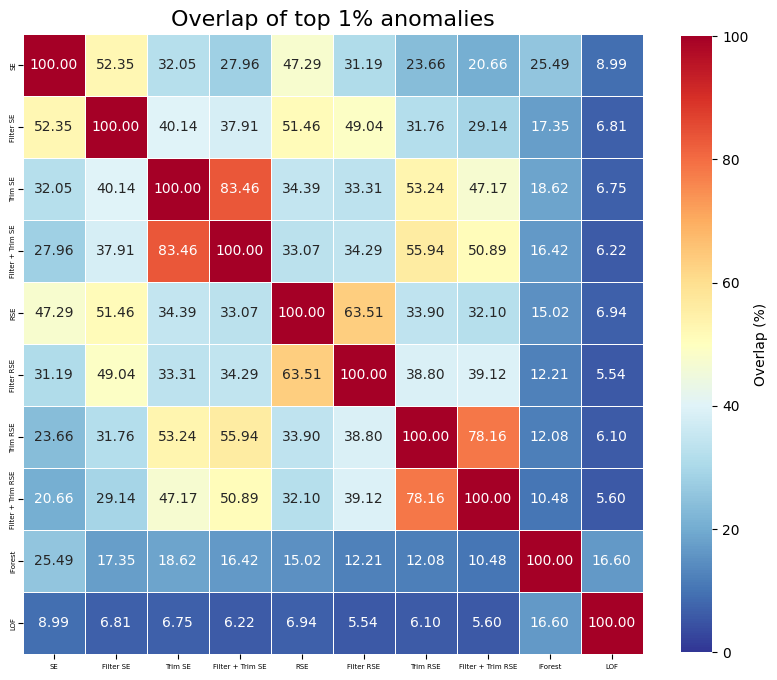

In [30]:
fig = plt.figure(figsize=(10, 10))
all_scores = se_cols + rse_cols + ["iforest", "lof"]
mapped_all_scores = [score_name_map[s] for s in all_scores]

sns.heatmap(
    overlap_df.loc[mapped_all_scores, mapped_all_scores],
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Overlap (%)"},
)
plt.title("Overlap of top 1% anomalies", fontsize=16)
plt.xticks(rotation=0, ha="center", fontsize=5)
plt.yticks(rotation=90, ha="center", fontsize=5)

# save fig
# fig.savefig(
#     f"{ch_4_dir}/{bin_id}/overlap_ses_latent_{bin_id}.pdf", bbox_inches="tight"
# )

## SE Vs latent

(array([0.5, 1.5, 2.5, 3.5]),
 [Text(0, 0.5, 'SE'),
  Text(0, 1.5, 'Filter SE'),
  Text(0, 2.5, 'Trim SE'),
  Text(0, 3.5, 'Filter + Trim SE')])

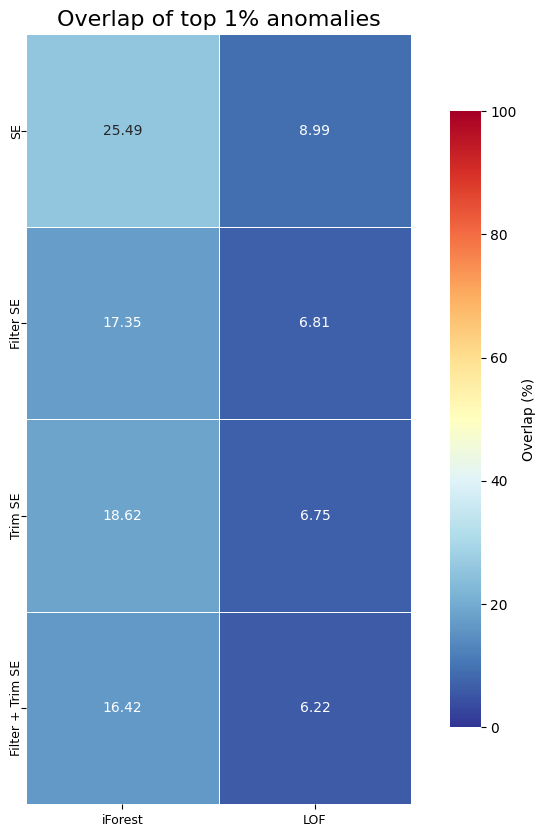

In [31]:
fig = plt.figure(figsize=(10, 10))

mapped_se_cols = [score_name_map[s] for s in se_cols]
latent_cols = ["iforest", "lof"]
mapped_latent_cols = [score_name_map[s] for s in latent_cols]

sns.heatmap(
    overlap_df.loc[mapped_se_cols, mapped_latent_cols],
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Overlap (%)"},
)

plt.title("Overlap of top 1% anomalies", fontsize=16)
plt.xticks(rotation=0, ha="center", fontsize=9)
plt.yticks(rotation=90, ha="center", fontsize=9)

## RSE Vs Latent

(array([0.5, 1.5, 2.5, 3.5]),
 [Text(0, 0.5, 'RSE'),
  Text(0, 1.5, 'Filter RSE'),
  Text(0, 2.5, 'Trim RSE'),
  Text(0, 3.5, 'Filter + Trim RSE')])

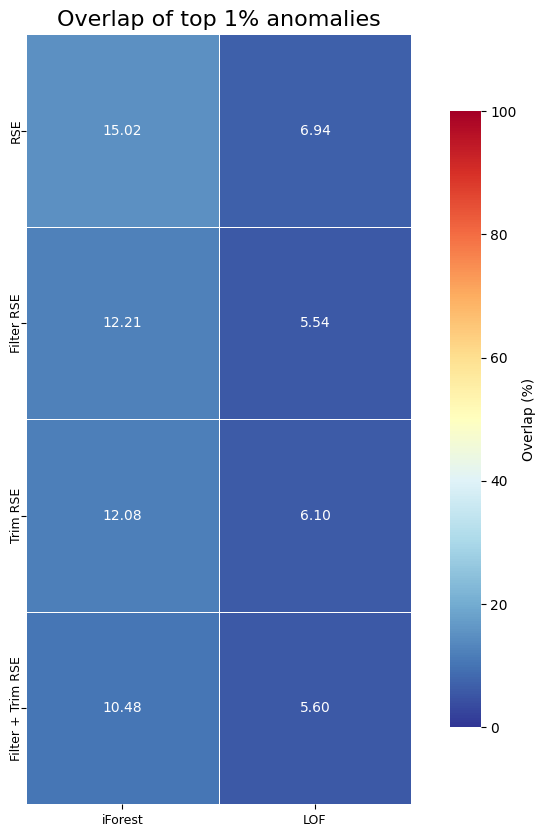

In [32]:
fig = plt.figure(figsize=(10, 10))

mapped_rse_cols = [score_name_map[s] for s in rse_cols]
latent_cols = ["iforest", "lof"]
mapped_latent_cols = [score_name_map[s] for s in latent_cols]

sns.heatmap(
    overlap_df.loc[mapped_rse_cols, mapped_latent_cols],
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Overlap (%)"},
)

plt.title("Overlap of top 1% anomalies", fontsize=16)
plt.xticks(rotation=0, ha="center", fontsize=9)
plt.yticks(rotation=90, ha="center", fontsize=9)

## SE family

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5]),
 [Text(0, 0.5, 'SE'),
  Text(0, 1.5, 'Filter SE'),
  Text(0, 2.5, 'Trim SE'),
  Text(0, 3.5, 'Filter + Trim SE'),
  Text(0, 4.5, 'iForest'),
  Text(0, 5.5, 'LOF')])

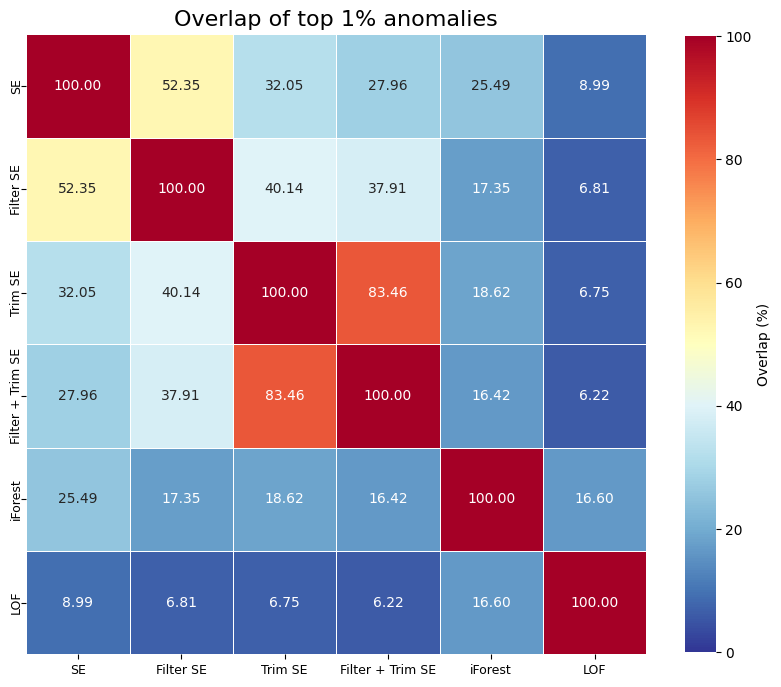

In [33]:
fig = plt.figure(figsize=(10, 10))
se_latent_cols = se_cols + ["iforest", "lof"]
mapped_se_cols = [score_name_map[s] for s in se_latent_cols]

sns.heatmap(
    overlap_df.loc[mapped_se_cols, mapped_se_cols],
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Overlap (%)"},
)
plt.title("Overlap of top 1% anomalies", fontsize=16)
plt.xticks(rotation=0, ha="center", fontsize=9)
plt.yticks(rotation=90, ha="center", fontsize=9)

# save fig
# fig.savefig(
#     f"{ch_4_dir}/{bin_id}/overlap_ses_latent_{bin_id}.pdf", bbox_inches="tight"
# )

## RSE family

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5]),
 [Text(0, 0.5, 'RSE'),
  Text(0, 1.5, 'Filter RSE'),
  Text(0, 2.5, 'Trim RSE'),
  Text(0, 3.5, 'Filter + Trim RSE'),
  Text(0, 4.5, 'iForest'),
  Text(0, 5.5, 'LOF')])

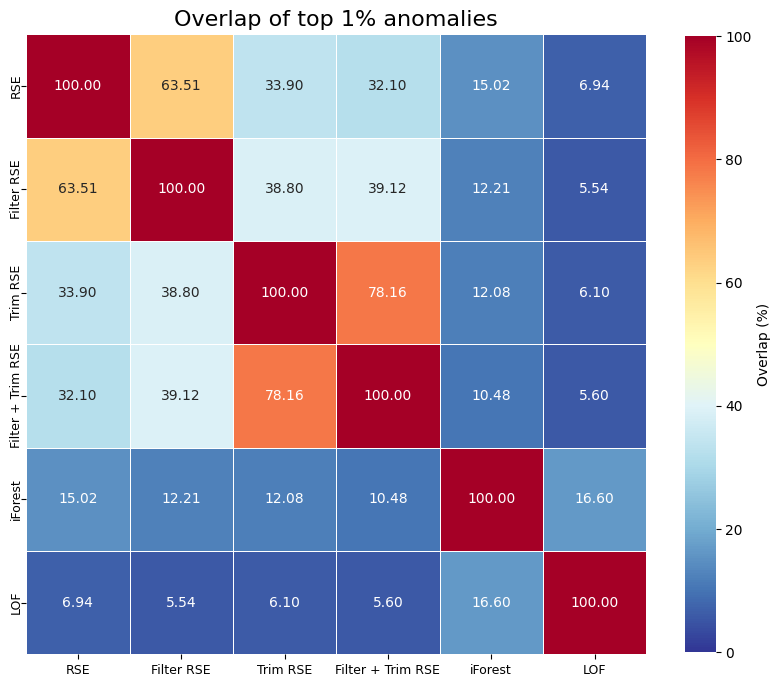

In [34]:
fig = plt.figure(figsize=(10, 10))
rse_latent_cols = rse_cols + ["iforest", "lof"]
mapped_rse_cols = [score_name_map[s] for s in rse_latent_cols]

sns.heatmap(
    overlap_df.loc[mapped_rse_cols, mapped_rse_cols],
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Overlap (%)"},
)

plt.title("Overlap of top 1% anomalies", fontsize=16)

plt.xticks(rotation=0, ha="center", fontsize=9)
plt.yticks(rotation=90, ha="center", fontsize=9)


# fig.savefig(
#     f"{ch_4_dir}/{bin_id}/overlap_rses_latent_{bin_id}.pdf", bbox_inches="tight"
# )

## SE Vs RSE

(array([0.5, 1.5, 2.5, 3.5]),
 [Text(0, 0.5, 'SE'),
  Text(0, 1.5, 'Filter SE'),
  Text(0, 2.5, 'Trim SE'),
  Text(0, 3.5, 'Filter + Trim SE')])

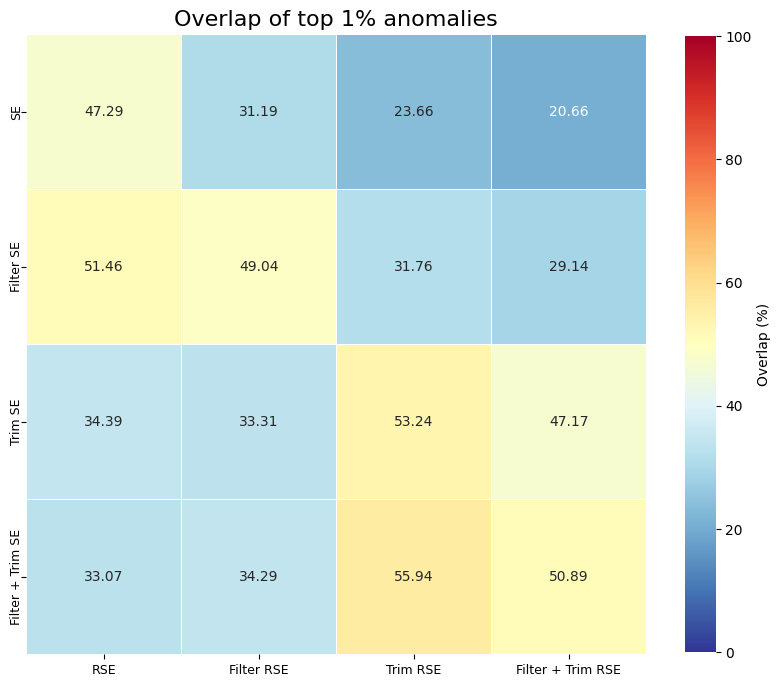

In [35]:
fig = plt.figure(figsize=(10, 10))

mapped_se_cols = [score_name_map[s] for s in se_cols]
mapped_rse_cols = [score_name_map[s] for s in rse_cols]

sns.heatmap(
    overlap_df.loc[mapped_se_cols, mapped_rse_cols],
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Overlap (%)"},
)

plt.title("Overlap of top 1% anomalies", fontsize=16)
plt.xticks(rotation=0, ha="center", fontsize=9)
plt.yticks(rotation=90, ha="center", fontsize=9)

# fig.savefig(
#     f"{ch_4_dir}/{bin_id}/overlap_all_{bin_id}.pdf",
#     bbox_inches='tight'
# )